In [21]:
import os
import glob
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import MessagePassing
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)


In [ ]:
DATA_DIR = 'parsed_graphs'                  


TARGET_GRAPH_FILES = 'all'


INFERENCE_TARGETS = ['CO2_728_graph.pt', 'CO2_828_graph.pt']


EXCLUDE_INFERENCE_FROM_TRAINING = True


CLASS_NAMES = ['clean', 'qn_shift', 'qn_swap', 'random_relink']
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

CORRUPTION_RATE = 0.08                      
ERROR_WEIGHTS = {                           
    'qn_shift': 0.40,                       
    'qn_swap': 0.30,                        
    'random_relink': 0.30                   
}
TRAIN_SPLIT_RATIO = 0.80                        
NUM_LAYERS = 5                              
HIDDEN_DIM = 64                             
LEARNING_RATE = 0.001                       
WEIGHT_DECAY = 1e-4                        
EPOCHS = 1000
LAMBDA_ENERGY = 0.5                                                     
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Using compute device: {DEVICE}")
print(f"Multi-Class Targets: {CLASS_NAMES} (NUM_CLASSES = {NUM_CLASSES})")


def resolve_graph_files(spec, data_dir=DATA_DIR, exclude_specs=None):
    """
    Resolves a file specification into a list of existing full filepaths.
    Supports single filename, list/tuple/set of filenames, glob patterns, or 'all'.
    Optionally subtracts excluded files (e.g. inference targets held out from training).
    """
    if not spec:
        return []

    all_dir_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.pt')])
    resolved_basenames = []

    if isinstance(spec, str):
        if spec.lower() == 'all':
            resolved_basenames = all_dir_files.copy()
        elif any(c in spec for c in '*?[]'):
            matched = glob.glob(os.path.join(data_dir, spec))
            resolved_basenames = [os.path.basename(m) for m in matched]
        else:
            resolved_basenames = [os.path.basename(spec)]
    elif isinstance(spec, (list, tuple, set)):
        for item in spec:
            if any(c in item for c in '*?[]'):
                matched = glob.glob(os.path.join(data_dir, item))
                resolved_basenames.extend([os.path.basename(m) for m in matched])
            else:
                resolved_basenames.append(os.path.basename(item))


    seen = set()
    deduped = []
    for f in resolved_basenames:
        if f not in seen:
            seen.add(f)
            deduped.append(f)

    if exclude_specs:
        excluded_basenames = set()
        if isinstance(exclude_specs, str):
            if exclude_specs.lower() == 'all':
                excluded_basenames = set(all_dir_files)
            elif any(c in exclude_specs for c in '*?[]'):
                excluded_basenames = {os.path.basename(m) for m in glob.glob(os.path.join(data_dir, exclude_specs))}
            else:
                excluded_basenames = {os.path.basename(exclude_specs)}
        elif isinstance(exclude_specs, (list, tuple, set)):
            for item in exclude_specs:
                if any(c in item for c in '*?[]'):
                    excluded_basenames.update(os.path.basename(m) for m in glob.glob(os.path.join(data_dir, item)))
                else:
                    excluded_basenames.add(os.path.basename(item))

        initial_len = len(deduped)
        deduped = [f for f in deduped if f not in excluded_basenames]
        num_excluded = initial_len - len(deduped)
        if num_excluded > 0:
            print(f"[Resolver] Excluded {num_excluded} inference file(s) from target list: {sorted(list(excluded_basenames))}")


    final_paths = []
    for f in deduped:
        p = os.path.join(data_dir, f)
        if os.path.exists(p):
            final_paths.append(p)
        else:
            print(f"Warning: Graph file not found: {p}")

    return final_paths


Using compute device: cuda
Multi-Class Targets: ['clean', 'qn_shift', 'qn_swap', 'random_relink'] (NUM_CLASSES = 4)


In [ ]:
def build_qn_neighbor_map(state_qns, num_nodes):
    if not state_qns or len(state_qns) == 0:
        return {}

    numeric_qns = []
    for qn in state_qns:
        num_vec = []
        for val in qn:
            try:
                num_vec.append(float(val))
            except (ValueError, TypeError):
                num_vec.append(hash(str(val)) % 1000)
        numeric_qns.append(np.array(num_vec))
    numeric_qns = np.array(numeric_qns)

    neighbor_map = {}
    for i in range(num_nodes):
        start = max(0, i - 100)
        end = min(num_nodes, i + 100)
        window = numeric_qns[start:end]
        diffs = np.sum(np.abs(window - numeric_qns[i]), axis=1)
        valid_local = np.where((diffs > 0) & (diffs <= 2.0))[0]
        
        if len(valid_local) > 0:
            neighbor_map[i] = (start + valid_local).tolist()
        else:
            neighbor_map[i] = [max(0, i - 1), min(num_nodes - 1, i + 1)]

    return neighbor_map


def perturb_transitions(raw_data, corruption_rate=CORRUPTION_RATE, error_weights=ERROR_WEIGHTS, neighbor_map=None):
    num_nodes = raw_data.num_nodes if hasattr(raw_data, 'num_nodes') and raw_data.num_nodes is not None else raw_data.x.shape[0]
    total_directed_edges = raw_data.edge_index.shape[1]
    num_transitions = total_directed_edges // 2

    src_nodes = raw_data.edge_index[0, :num_transitions].clone().cpu().numpy()
    dst_nodes = raw_data.edge_index[1, :num_transitions].clone().cpu().numpy()
    fwd_attr = raw_data.edge_attr[:num_transitions].clone().cpu().numpy()

    num_corrupt = max(1, int(num_transitions * corruption_rate))
    corrupt_indices = np.random.choice(num_transitions, size=num_corrupt, replace=False)
    corrupt_mask = np.zeros(num_transitions, dtype=bool)
    corrupt_mask[corrupt_indices] = True


    corruption_types = np.array(['clean'] * num_transitions, dtype=object)

    types = list(error_weights.keys())
    probs = np.array([error_weights[t] for t in types])
    probs = probs / probs.sum()

    for idx in corrupt_indices:
        err_type = np.random.choice(types, p=probs)
        corruption_types[idx] = err_type
        u, v = src_nodes[idx], dst_nodes[idx]

        if err_type == 'qn_shift':
            target_node = v if np.random.rand() > 0.5 else u
            if neighbor_map and target_node in neighbor_map and len(neighbor_map[target_node]) > 0:
                new_node = np.random.choice(neighbor_map[target_node])
            else:
                offset = np.random.choice([-2, -1, 1, 2])
                new_node = int(np.clip(target_node + offset, 0, num_nodes - 1))
            
            if target_node == v:
                dst_nodes[idx] = new_node
            else:
                src_nodes[idx] = new_node

        elif err_type == 'qn_swap':
            src_nodes[idx] = v
            dst_nodes[idx] = u

        elif err_type == 'random_relink':
            rand_node = np.random.randint(0, num_nodes)
            while rand_node == u:
                rand_node = np.random.randint(0, num_nodes)
            dst_nodes[idx] = rand_node

    new_src = np.concatenate([src_nodes, dst_nodes])
    new_dst = np.concatenate([dst_nodes, src_nodes])
    edge_index = torch.tensor(np.stack([new_src, new_dst]), dtype=torch.long)

    rev_attr = fwd_attr.copy()
    rev_attr[:, 0] = -rev_attr[:, 0]
    edge_attr = torch.tensor(np.concatenate([fwd_attr, rev_attr], axis=0), dtype=torch.float)

  
    fwd_labels = corrupt_mask.astype(np.float32)
    edge_labels = torch.tensor(np.concatenate([fwd_labels, fwd_labels]), dtype=torch.float)

    fwd_class_labels = np.array([CLASS_TO_IDX[t] for t in corruption_types], dtype=np.int64)
    edge_class_label = torch.tensor(np.concatenate([fwd_class_labels, fwd_class_labels]), dtype=torch.long)

    corrupted_data = Data(
        edge_index=edge_index,
        edge_attr=edge_attr,
        edge_label=edge_labels,
        edge_class_label=edge_class_label,
        num_nodes=num_nodes,
        num_transitions=num_transitions,
        num_corrupt=num_corrupt,
        molecule_name=getattr(raw_data, 'molecule_name', 'Unknown')
    )
    corrupted_data.corruption_types = corruption_types
    return corrupted_data


def perturb_multi_graphs(raw_graphs, neighbor_maps, corruption_rate=CORRUPTION_RATE, error_weights=ERROR_WEIGHTS):
    """
    Independently corrupts each graph using its own neighbor map,
    tracks multi-class corruption labels, and combines them into a block-diagonal PyG Batch.
    """
    corrupted_list = []
    for i, g in enumerate(raw_graphs):
        nm = neighbor_maps[i]
        c_data = perturb_transitions(g, corruption_rate=corruption_rate, error_weights=error_weights, neighbor_map=nm)
        corrupted_list.append(c_data)

    batch = Batch.from_data_list(corrupted_list)
    batch.corruption_types = np.concatenate([c.corruption_types for c in corrupted_list])
    return batch


In [ ]:
class SpectroConv(MessagePassing):
    def __init__(self, hidden_dim):
        super(SpectroConv, self).__init__(aggr='mean')

        self.msg_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.energy_proj = nn.Linear(1, hidden_dim)

        self.update_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        trans_E = edge_attr[:, 0:1]
        state_interaction = self.msg_mlp(torch.cat([x_i, x_j], dim=-1))
        energy_shift = self.energy_proj(trans_E)
        return state_interaction + energy_shift

    def update(self, aggr_out, x):
        new_state = torch.cat([x, aggr_out], dim=-1)
        return self.update_mlp(new_state) + x


class TransitionAnomalyGNN(nn.Module):
    def __init__(self, num_layers=NUM_LAYERS, hidden_dim=HIDDEN_DIM, num_classes=NUM_CLASSES):
        super().__init__()

        self.init_node_feature = nn.Parameter(torch.zeros(1, hidden_dim))

        self.convs = nn.ModuleList([
            SpectroConv(hidden_dim) for _ in range(num_layers)
        ])


        self.node_energy_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )


        in_dim = (2 * hidden_dim) + 2 + 1
        self.edge_classifier = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, edge_index, edge_attr, num_nodes=None):
        if num_nodes is None:
            num_nodes = int(edge_index.max().item()) + 1

        h = self.init_node_feature.expand(num_nodes, -1)

        for conv in self.convs:
            h = conv(h, edge_index, edge_attr)

        node_energies = self.node_energy_head(h).squeeze(-1) 

        u_nodes = edge_index[0]
        v_nodes = edge_index[1]

        h_u = h[u_nodes]
        h_v = h[v_nodes]
        h_diff = h_v - h_u
        h_diff_abs = torch.abs(h_diff)


        pred_delta_E = node_energies[v_nodes] - node_energies[u_nodes]
        obs_wavenumber = edge_attr[:, 0]
        obs_uncertainty = torch.clamp(edge_attr[:, 1], min=1e-6)

        norm_res = (obs_wavenumber - pred_delta_E) / obs_uncertainty
        log_res = torch.sign(norm_res) * torch.log1p(torch.abs(norm_res))
        res_feat = log_res.unsqueeze(-1)

        edge_features = torch.cat([h_diff, h_diff_abs, edge_attr, res_feat], dim=-1)
        edge_logits = self.edge_classifier(edge_features) 

        return edge_logits, node_energies, norm_res


In [ ]:
def train_and_evaluate(raw_graphs, epochs=EPOCHS, lr=LEARNING_RATE, device=DEVICE):
    if not isinstance(raw_graphs, list):
        raw_graphs = [raw_graphs]

    num_graphs = len(raw_graphs)
    total_nodes = 0
    total_transitions = 0
    graph_info = []

    print(f"=== Multi-Graph Multi-Class Training & Evaluation Setup ===")
    print(f"Number of target graphs: {num_graphs}")

    neighbor_maps = []
    for i, g in enumerate(raw_graphs):
        n_nodes = g.num_nodes if hasattr(g, 'num_nodes') and g.num_nodes is not None else g.x.shape[0]
        n_trans = g.edge_index.shape[1] // 2
        mol_name = getattr(g, 'molecule_name', f"Graph_{i+1}")
        total_nodes += n_nodes
        total_transitions += n_trans

        st_qns = getattr(g, 'state_qns', None)
        nm = build_qn_neighbor_map(st_qns, n_nodes)
        neighbor_maps.append(nm)

        graph_info.append({
            'idx': i,
            'name': mol_name,
            'num_nodes': n_nodes,
            'num_transitions': n_trans,
            'directed_edges': n_trans * 2
        })
        print(f"  [{i+1}/{num_graphs}] {mol_name}: {n_nodes:,} nodes, {n_trans:,} transitions")

    print(f"Total Cumulative Nodes: {total_nodes:,} | Total Transitions: {total_transitions:,}")


    all_train_edge_indices = []
    all_val_edge_indices = []
    all_val_trans_indices = []
    per_graph_val_indices = {}

    current_edge_offset = 0
    current_trans_offset = 0
    np.random.seed(SEED)

    for i, info in enumerate(graph_info):
        m_k = info['num_transitions']
        perm = np.random.permutation(m_k)
        split_pt = int(m_k * TRAIN_SPLIT_RATIO)
        
        train_local = perm[:split_pt]
        val_local = perm[split_pt:]

        train_batch = current_edge_offset + train_local
        val_batch = current_edge_offset + val_local
        val_trans_batch = current_trans_offset + val_local

        all_train_edge_indices.extend(train_batch)
        all_val_edge_indices.extend(val_batch)
        all_val_trans_indices.extend(val_trans_batch)
        per_graph_val_indices[info['name']] = val_batch

        current_edge_offset += 2 * m_k
        current_trans_offset += m_k

    train_mask = torch.tensor(all_train_edge_indices, dtype=torch.long, device=device)
    val_mask = torch.tensor(all_val_edge_indices, dtype=torch.long, device=device)

    total_train = len(train_mask)
    total_val = len(val_mask)


    clean_freq = 1.0 - CORRUPTION_RATE
    shift_freq = CORRUPTION_RATE * ERROR_WEIGHTS['qn_shift']
    swap_freq = CORRUPTION_RATE * ERROR_WEIGHTS['qn_swap']
    relink_freq = CORRUPTION_RATE * ERROR_WEIGHTS['random_relink']

    weights = [
        1.0,
        clean_freq / shift_freq,
        clean_freq / swap_freq,
        clean_freq / relink_freq
    ]
    class_weights = torch.tensor(weights, dtype=torch.float, device=device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    model = TransitionAnomalyGNN(num_layers=NUM_LAYERS, hidden_dim=HIDDEN_DIM, num_classes=NUM_CLASSES).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)

    print(f"Train Transitions: {total_train:,} | Val Transitions: {total_val:,}")
    print(f"Class Weights: {np.round(weights, 2)} | Device: {device}")
    print()

    train_loss_history = []
    train_energy_history = []
    val_loss_history = []
    val_roc_history = []
    val_pr_history = []

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        batch_data = perturb_multi_graphs(raw_graphs, neighbor_maps, corruption_rate=CORRUPTION_RATE).to(device)

        model.train()
        optimizer.zero_grad()

        edge_logits, node_energies, norm_res = model(batch_data.edge_index, batch_data.edge_attr, num_nodes=batch_data.num_nodes)
        train_logits = edge_logits[train_mask]
        train_targets = batch_data.edge_class_label[train_mask]
        train_class_loss = loss_fn(train_logits, train_targets)


        clean_train_mask = (train_targets == 0)
        if clean_train_mask.sum() > 0:
            clean_residuals = norm_res[train_mask][clean_train_mask]
            energy_loss = F.smooth_l1_loss(
                torch.log1p(torch.abs(clean_residuals)),
                torch.zeros_like(clean_residuals),
                beta=1.0
            )
        else:
            energy_loss = torch.tensor(0.0, device=device)

        train_loss = train_class_loss + LAMBDA_ENERGY * energy_loss
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits, _, val_norm_res = model(batch_data.edge_index, batch_data.edge_attr, num_nodes=batch_data.num_nodes)
            val_sub_logits = val_logits[val_mask]
            val_targets = batch_data.edge_class_label[val_mask]
            val_class_loss = loss_fn(val_sub_logits, val_targets)

            clean_val_mask = (val_targets == 0)
            if clean_val_mask.sum() > 0:
                val_residuals = val_norm_res[val_mask][clean_val_mask]
                val_energy_loss = F.smooth_l1_loss(
                    torch.log1p(torch.abs(val_residuals)),
                    torch.zeros_like(val_residuals),
                    beta=1.0
                )
            else:
                val_energy_loss = torch.tensor(0.0, device=device)

            val_loss = val_class_loss + LAMBDA_ENERGY * val_energy_loss

            val_probs = F.softmax(val_sub_logits, dim=-1).cpu().numpy()
            val_anomaly_probs = 1.0 - val_probs[:, 0]
            val_binary_targets = (val_targets.cpu().numpy() > 0).astype(int)

            val_roc = roc_auc_score(val_binary_targets, val_anomaly_probs) if len(np.unique(val_binary_targets)) > 1 else 0.5
            val_pr = average_precision_score(val_binary_targets, val_anomaly_probs) if len(np.unique(val_binary_targets)) > 1 else 0.0

        train_loss_history.append(train_loss.item())
        train_energy_history.append(energy_loss.item())
        val_loss_history.append(val_loss.item())
        val_roc_history.append(val_roc)
        val_pr_history.append(val_pr)

        if epoch % 50 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d}/{epochs:03d} | Total Loss: {train_loss.item():.4f} (Class: {train_class_loss.item():.4f}, E: {energy_loss.item():.4f}) | Val Loss: {val_loss.item():.4f} | Overall ROC-AUC: {val_roc:.4f} | PR-AUC: {val_pr:.4f}", flush=True)

    elapsed = time.time() - start_time
    print(f"\nTraining completed in {elapsed:.2f}s.")


    model.eval()
    with torch.no_grad():
        final_batch = perturb_multi_graphs(raw_graphs, neighbor_maps, corruption_rate=CORRUPTION_RATE).to(device)
        logits, node_energies, norm_res = model(final_batch.edge_index, final_batch.edge_attr, num_nodes=final_batch.num_nodes)
        
        pooled_logits = logits[val_mask]
        pooled_probs = F.softmax(pooled_logits, dim=-1).cpu().numpy()
        pooled_class_targets = final_batch.edge_class_label[val_mask].cpu().numpy()
        pooled_binary_targets = (pooled_class_targets > 0).astype(int)
        pooled_residuals = norm_res[val_mask].cpu().numpy()
        
        pooled_anomaly_probs = 1.0 - pooled_probs[:, 0]
        pooled_types = final_batch.corruption_types[all_val_trans_indices]

    final_roc = roc_auc_score(pooled_binary_targets, pooled_anomaly_probs)
    final_pr_auc = average_precision_score(pooled_binary_targets, pooled_anomaly_probs)

    precision_curve, recall_curve, thresholds = precision_recall_curve(pooled_binary_targets, pooled_anomaly_probs)
    f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-8)
    best_thresh_idx = np.argmax(f1_scores)
    best_threshold = float(thresholds[best_thresh_idx]) if best_thresh_idx < len(thresholds) else 0.5
    best_f1 = f1_scores[best_thresh_idx]

    preds_binary = (pooled_anomaly_probs >= best_threshold).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(pooled_binary_targets, preds_binary, average='binary', zero_division=0)
    
    pred_classes = np.argmax(pooled_probs, axis=-1)
    cm_4x4 = confusion_matrix(pooled_class_targets, pred_classes, labels=[0, 1, 2, 3])

    print(f"=== Multi-Class Model Performance ===")
    print(f" Overall ROC-AUC Score:     {final_roc:.4f}")
    print(f" Overall PR-AUC Score:      {final_pr_auc:.4f}")
    print(f" Best Anomaly Threshold:    {best_threshold:.4f} (Max F1 = {best_f1:.4f})")
    print(f" Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}\n")


    clean_mask = (pooled_class_targets == 0)
    clean_probs = pooled_anomaly_probs[clean_mask]
    clean_total = len(clean_probs)
    clean_fp = int(np.sum(clean_probs >= best_threshold))
    clean_spec = (1.0 - clean_fp / clean_total) * 100.0 if clean_total > 0 else 100.0
    clean_median_res = float(np.median(np.abs(pooled_residuals[clean_mask])))

    print("=" * 105)
    print(f"{'MULTI-CLASS FAILURE MODE BREAKDOWN (Anomaly Threshold = ' + f'{best_threshold:.4f})':^105}")
    print("=" * 105)
    print(f"{'Class':<16} {'Total':<10} {'Detected (TP)':<15} {'Missed (FN)':<13} {'Recall (% Caught)':<20} {'One-vs-Clean AUC':<18} {'Median |Res/unc|':<16}")
    print("-" * 105)

    error_classes = [1, 2, 3]
    type_stats = {}
    type_rocs = {}

    for c_idx in error_classes:
        c_name = CLASS_NAMES[c_idx]
        mask = (pooled_class_targets == c_idx)
        n = int(np.sum(mask))
        if n == 0:
            continue
        c_anomaly_p = pooled_anomaly_probs[mask]
        detected = int(np.sum(c_anomaly_p >= best_threshold))
        missed = n - detected
        recall_pct = (detected / n) * 100.0 if n > 0 else 0.0
        median_res = float(np.median(np.abs(pooled_residuals[mask])))


        sub_y = np.concatenate([np.zeros(len(clean_probs)), np.ones(n)])
        sub_p = np.concatenate([pooled_probs[clean_mask, c_idx], pooled_probs[mask, c_idx]])
        if len(np.unique(sub_y)) > 1:
            auc_val = roc_auc_score(sub_y, sub_p)
            fpr_c, tpr_c, _ = roc_curve(sub_y, sub_p)
            type_rocs[c_name] = (fpr_c, tpr_c, auc_val)
        else:
            auc_val = 0.5

        type_stats[c_name] = {
            'total': n,
            'detected': detected,
            'missed': missed,
            'recall': recall_pct,
            'auc': auc_val,
            'probs': c_anomaly_p,
            'class_probs': pooled_probs[mask, c_idx],
            'median_res': median_res
        }

        print(f"{c_name:<16} {n:<10,} {detected:<15,} {missed:<13,} {recall_pct:>6.2f}%{'':<13} {auc_val:>8.4f}             {median_res:>10.2f}")

    print("-" * 105)
    print(f"{'Clean (Baseline)':<16} {clean_total:<10,} {'N/A (TN=' + f'{clean_total-clean_fp:,})':<15} {'FP=' + f'{clean_fp:,}':<13} {clean_spec:>6.2f}% (Specificity) {'N/A':<18}   {clean_median_res:>10.2f}")
    print("=" * 105 + "\n")


    fig1, axs1 = plt.subplots(1, 3, figsize=(18, 5))

    axs1[0].plot(train_loss_history, label='Total Train Loss', color='royalblue')
    axs1[0].plot(val_loss_history, label='Val Loss', color='crimson')
    axs1[0].plot(train_energy_history, label='Energy Residual Loss', color='darkorange', linestyle='--')
    axs1[0].set_xlabel('Epoch')
    axs1[0].set_ylabel('Loss Value')
    axs1[0].set_title(f'Multi-Task Training Loss ({num_graphs} Target Graphs)')
    axs1[0].legend()
    axs1[0].grid(True, linestyle='--', alpha=0.6)

    fpr_pooled, tpr_pooled, _ = roc_curve(pooled_binary_targets, pooled_anomaly_probs)
    axs1[1].plot(fpr_pooled, tpr_pooled, color='darkorange', lw=2, label=f'Overall ROC (AUC = {final_roc:.3f})')
    axs1[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axs1[1].set_xlabel('False Positive Rate')
    axs1[1].set_ylabel('True Positive Rate')
    axs1[1].set_title('Overall Anomaly ROC Curve')
    axs1[1].legend(loc='lower right')
    axs1[1].grid(True, linestyle='--', alpha=0.6)

    axs1[2].hist(clean_probs, bins=30, alpha=0.6, color='seagreen', label=f'Clean (N={len(clean_probs)})')
    axs1[2].hist(pooled_anomaly_probs[pooled_binary_targets == 1], bins=30, alpha=0.6, color='firebrick', label=f'All Anomalies (N={int(np.sum(pooled_binary_targets))})')
    axs1[2].axvline(best_threshold, color='black', linestyle=':', lw=2, label=f'Thresh ({best_threshold:.2f})')
    axs1[2].set_xlabel('Predicted Anomaly Probability (1 - P_clean)')
    axs1[2].set_ylabel('Count')
    axs1[2].set_title('Anomaly Score Separation')
    axs1[2].legend()
    axs1[2].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


    fig2, axs2 = plt.subplots(2, 2, figsize=(16, 12))

    palette = {
        'clean': 'seagreen',
        'qn_shift': 'royalblue',
        'qn_swap': 'darkorange',
        'random_relink': 'crimson'
    }


    axs2[0, 0].hist(clean_probs, bins=30, density=True, alpha=0.4, color=palette['clean'], label=f'Clean (N={len(clean_probs)})')
    for c_name in ['qn_shift', 'qn_swap', 'random_relink']:
        if c_name in type_stats:
            p_vals = type_stats[c_name]['probs']
            axs2[0, 0].hist(p_vals, bins=30, density=True, histtype='step', lw=2.5, color=palette.get(c_name, 'purple'), label=f"{c_name} (N={len(p_vals)})")
    axs2[0, 0].axvline(best_threshold, color='black', linestyle='--', lw=2, label=f'Threshold ({best_threshold:.2f})')
    axs2[0, 0].set_xlabel('Anomaly Probability (1.0 - P_clean)')
    axs2[0, 0].set_ylabel('Density')
    axs2[0, 0].set_title('1. Softmax Anomaly Separation by Corruption Type', fontsize=12, fontweight='bold')
    axs2[0, 0].legend(loc='upper right')
    axs2[0, 0].grid(True, linestyle='--', alpha=0.5)


    axs2[0, 1].plot([0, 1], [0, 1], color='gray', linestyle=':')
    for c_name in ['qn_shift', 'qn_swap', 'random_relink']:
        if c_name in type_rocs:
            fpr_c, tpr_c, auc_c = type_rocs[c_name]
            axs2[0, 1].plot(fpr_c, tpr_c, lw=2.2, color=palette.get(c_name, 'purple'), label=f"{c_name} (AUC = {auc_c:.3f})")
    axs2[0, 1].set_xlabel('False Positive Rate')
    axs2[0, 1].set_ylabel('True Positive Rate')
    axs2[0, 1].set_title('2. Dedicated Multi-Class ROC Curves', fontsize=12, fontweight='bold')
    axs2[0, 1].legend(loc='lower right')
    axs2[0, 1].grid(True, linestyle='--', alpha=0.5)


    bar_labels = [c for c in ['qn_shift', 'qn_swap', 'random_relink'] if c in type_stats]
    detected_rates = [type_stats[c]['recall'] for c in bar_labels]
    missed_rates = [100.0 - r for r in detected_rates]

    x_pos = np.arange(len(bar_labels))
    axs2[1, 0].bar(x_pos, detected_rates, color='#2ca02c', alpha=0.85, label='Detected (TP %)')
    axs2[1, 0].bar(x_pos, missed_rates, bottom=detected_rates, color='#d62728', alpha=0.85, label='Missed / Failed (FN %)')
    axs2[1, 0].set_xticks(x_pos)
    axs2[1, 0].set_xticklabels(bar_labels, fontsize=11)
    axs2[1, 0].set_ylabel('Percentage of Corrupted Transitions (%)')
    axs2[1, 0].set_title('3. Multi-Class Detection vs Missed Rates', fontsize=12, fontweight='bold')
    axs2[1, 0].set_ylim(0, 105)
    axs2[1, 0].legend(loc='upper right')
    axs2[1, 0].grid(axis='y', linestyle='--', alpha=0.5)
    for i, (det, mis) in enumerate(zip(detected_rates, missed_rates)):
        axs2[1, 0].text(i, det / 2, f"{det:.1f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        if mis > 4.0:
            axs2[1, 0].text(i, det + (mis / 2), f"{mis:.1f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=10)


    cm_norm = cm_4x4.astype('float') / (cm_4x4.sum(axis=1)[:, np.newaxis] + 1e-8)
    im = axs2[1, 1].imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
    axs2[1, 1].figure.colorbar(im, ax=axs2[1, 1], fraction=0.046, pad=0.04)
    axs2[1, 1].set_xticks(np.arange(NUM_CLASSES))
    axs2[1, 1].set_yticks(np.arange(NUM_CLASSES))
    axs2[1, 1].set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=10)
    axs2[1, 1].set_yticklabels(CLASS_NAMES, fontsize=10)
    axs2[1, 1].set_xlabel('Predicted Label', fontweight='bold')
    axs2[1, 1].set_ylabel('True Label', fontweight='bold')
    axs2[1, 1].set_title('4. Normalized 4x4 Confusion Matrix', fontsize=12, fontweight='bold')

    thresh_cm = cm_norm.max() / 2.
    for r in range(NUM_CLASSES):
        for c in range(NUM_CLASSES):
            axs2[1, 1].text(c, r, f"{cm_norm[r, c]:.2f}\n({cm_4x4[r, c]})",
                            ha="center", va="center",
                            color="white" if cm_norm[r, c] > thresh_cm else "black",
                            fontsize=9)

    plt.tight_layout()
    plt.show()

    return model, best_threshold


[Resolver] Excluded 2 inference file(s) from target list: ['CO2_728_graph.pt', 'CO2_828_graph.pt']
Loading 13 training graph file(s):
  - Loaded CO2_838             : 1,170 nodes, 2,426 transitions
  - Loaded H2O_H217O           : 2,723 nodes, 9,034 transitions
  - Loaded H2O_H218O           : 5,172 nodes, 31,730 transitions
  - Loaded HDO_HD16O           : 8,967 nodes, 54,740 transitions
  - Loaded HDO_HD17O           : 171 nodes, 485 transitions
  - Loaded HDO_HD18O           : 1,939 nodes, 8,728 transitions
  - Loaded SO2_626             : 15,989 nodes, 40,325 transitions
  - Loaded SO2_636             : 6,301 nodes, 15,647 transitions
  - Loaded SO2_646             : 11,165 nodes, 31,088 transitions
  - Loaded SO2_666             : 61 nodes, 31 transitions
  - Loaded SO_33S16O           : 4,508 nodes, 29,137 transitions
  - Loaded SO_34S16O           : 4,904 nodes, 32,358 transitions
  - Loaded SO_36S16O           : 5,366 nodes, 35,668 transitions
=== Multi-Graph Multi-Class Traini

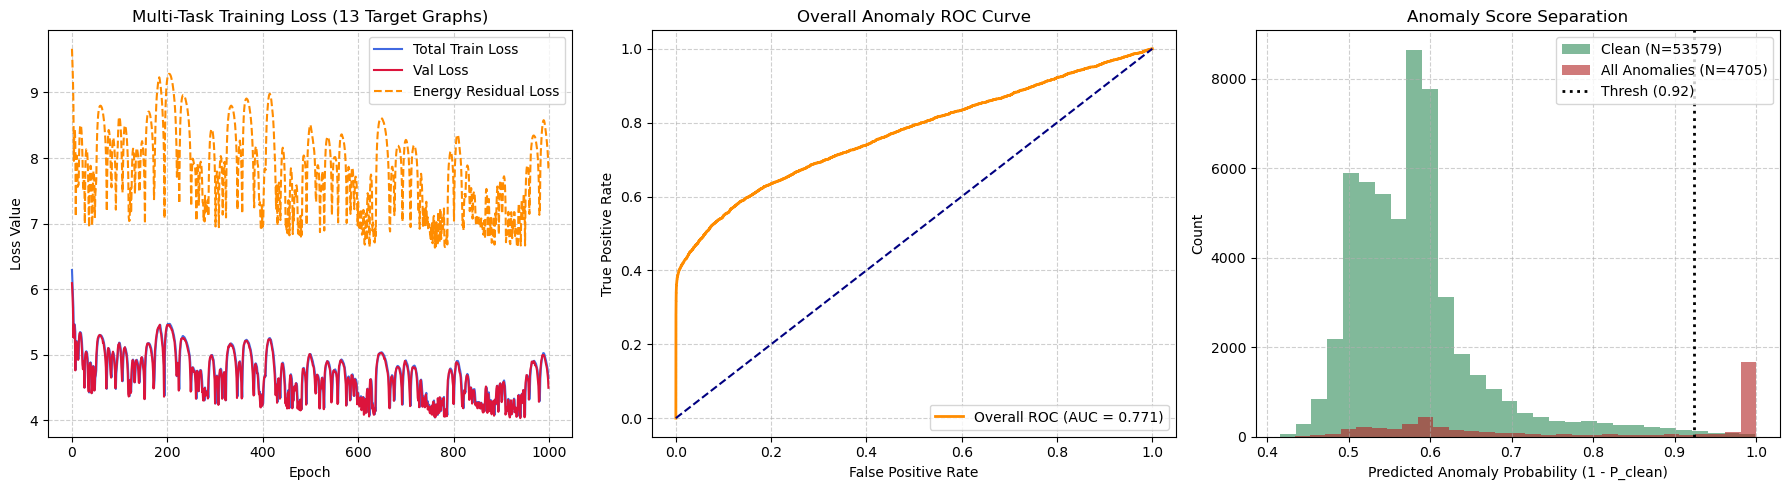

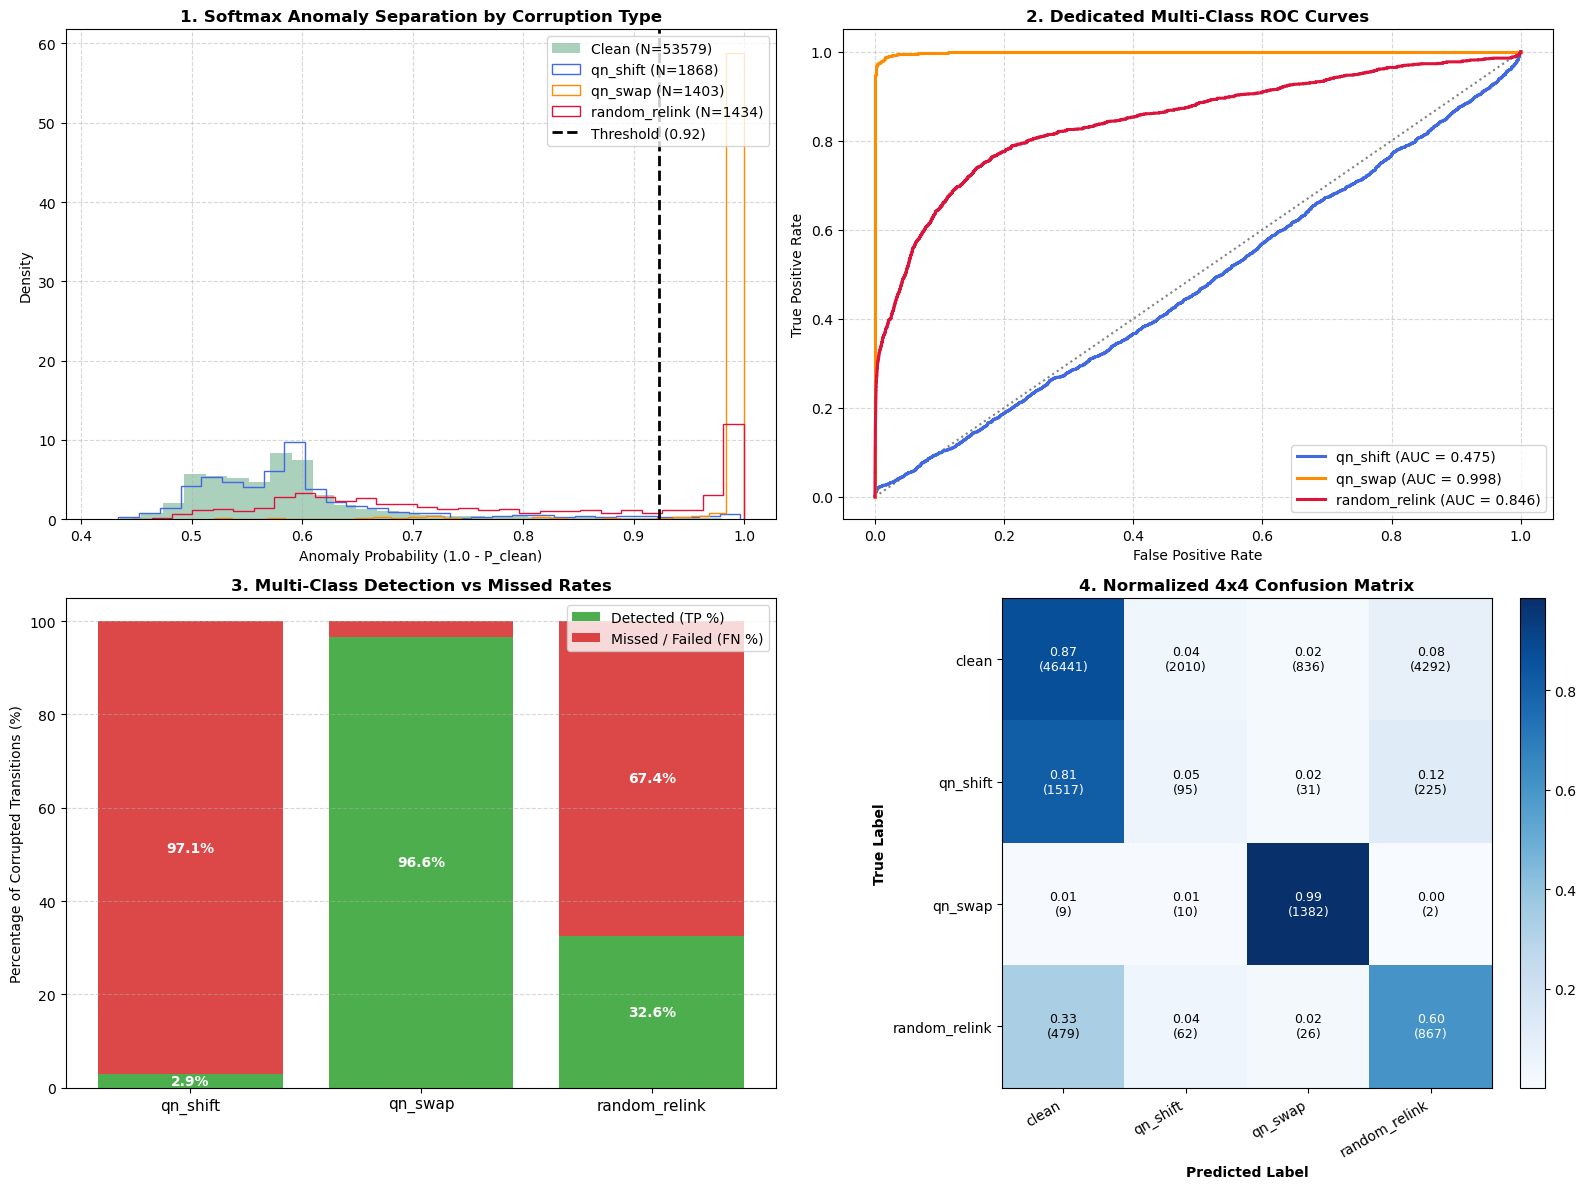

In [26]:
exclude_list = INFERENCE_TARGETS if EXCLUDE_INFERENCE_FROM_TRAINING else None
training_files = resolve_graph_files(TARGET_GRAPH_FILES, DATA_DIR, exclude_specs=exclude_list)

print(f"Loading {len(training_files)} training graph file(s):")
raw_graphs = []
for tf in training_files:
    raw_data = torch.load(tf, weights_only=False)
    mol_name = getattr(raw_data, 'molecule_name', os.path.basename(tf))
    nodes = raw_data.num_nodes if hasattr(raw_data, 'num_nodes') and raw_data.num_nodes is not None else raw_data.x.shape[0]
    trans = raw_data.edge_index.shape[1] // 2
    raw_graphs.append(raw_data)
    print(f"  - Loaded {mol_name:<20}: {nodes:,} nodes, {trans:,} transitions")

model, best_threshold = train_and_evaluate(raw_graphs, epochs=EPOCHS, lr=LEARNING_RATE, device=DEVICE)


In [ ]:
infer_files = resolve_graph_files(INFERENCE_TARGETS, DATA_DIR)

if infer_files:
    print(f"=== Running Multi-Class Physics-Informed Inference on {len(infer_files)} Target Graph File(s) ===")
    threshold = best_threshold if 'best_threshold' in locals() else 0.5
    print(f"Operating Anomaly Threshold = {threshold:.4f}\n")

    summary_rows = []

    for idx_f, ifile in enumerate(infer_files, 1):
        target_name = os.path.basename(ifile)
        infer_data = torch.load(ifile, weights_only=False)
        mol_name = getattr(infer_data, 'molecule_name', target_name)
        infer_nodes = infer_data.num_nodes if hasattr(infer_data, 'num_nodes') and infer_data.num_nodes is not None else infer_data.x.shape[0]
        infer_transitions = infer_data.edge_index.shape[1] // 2

        print(f"{'='*65}")
        print(f"[{idx_f}/{len(infer_files)}] Target Graph: {target_name} ({mol_name})")
        print(f"Nodes: {infer_nodes:,} | Transitions: {infer_transitions:,}")

        model.eval()
        with torch.no_grad():
            infer_logits, infer_energies, infer_residuals = model(
                infer_data.edge_index.to(DEVICE),
                infer_data.edge_attr.to(DEVICE),
                num_nodes=infer_nodes
            )
            fwd_logits = infer_logits[:infer_transitions]
            fwd_residuals = infer_residuals[:infer_transitions].cpu().numpy()
            fwd_probs = F.softmax(fwd_logits, dim=-1).cpu().numpy() 
            fwd_anomaly_probs = 1.0 - fwd_probs[:, 0]

        mean_p = float(fwd_anomaly_probs.mean())
        med_p = float(np.median(fwd_anomaly_probs))
        std_p = float(fwd_anomaly_probs.std())
        min_p = float(fwd_anomaly_probs.min())
        max_p = float(fwd_anomaly_probs.max())

        flagged_indices = np.where(fwd_anomaly_probs >= threshold)[0]
        flagged_count = len(flagged_indices)
        flagged_pct = (flagged_count / infer_transitions) * 100 if infer_transitions > 0 else 0.0

        print(f"  - Mean / Median Anomaly Prob:  {mean_p:.4f} / {med_p:.4f}")
        print(f"  - Std / Min / Max Prob:        {std_p:.4f} / {min_p:.4f} / {max_p:.4f}")
        print(f"  - Flagged Anomalies:           {flagged_count:,} / {infer_transitions:,} ({flagged_pct:.2f}%)")
        print(f"  - Clean Transitions:           {infer_transitions - flagged_count:,} ({100 - flagged_pct:.2f}%)")

        top_k = min(10, infer_transitions)
        top_indices = np.argsort(-fwd_anomaly_probs)[:top_k]

        src = infer_data.edge_index[0, :infer_transitions].cpu().numpy()
        dst = infer_data.edge_index[1, :infer_transitions].cpu().numpy()
        wavenumbers = infer_data.edge_attr[:infer_transitions, 0].cpu().numpy()
        uncertainties = infer_data.edge_attr[:infer_transitions, 1].cpu().numpy()

        print(f"\n  Top {top_k} Highest Anomaly Transitions with Predicted Diagnosis & Residuals:")
        print(f"  {'Rank':<5} {'Trans Idx':<10} {'From ID':<9} {'To ID':<9} {'Wavenumber':<16} {'Uncertainty':<14} {'|Res/unc|':<14} {'Anomaly P':<11} {'Predicted Diagnosis':<20} {'Conf':<8}")
        for rank, idx in enumerate(top_indices, 1):
            u_idx, v_idx = src[idx], dst[idx]
            wn = wavenumbers[idx]
            unc = uncertainties[idx]
            res_val = abs(float(fwd_residuals[idx]))
            p_anom = fwd_anomaly_probs[idx]
            

            corrupt_p = fwd_probs[idx, 1:]
            pred_diag_idx = np.argmax(corrupt_p) + 1
            pred_diag_name = CLASS_NAMES[pred_diag_idx]
            pred_diag_conf = corrupt_p[pred_diag_idx - 1]

            print(f"  {rank:<5} {idx:<10} {u_idx:<9} {v_idx:<9} {wn:<16.6f} {unc:<14.2e} {res_val:<14.2f} {p_anom:<11.4f} {pred_diag_name:<20} {pred_diag_conf:<8.4f}")
        print()

        summary_rows.append({
            'Target File': target_name,
            'Molecule': mol_name,
            'Total Transitions': infer_transitions,
            'Flagged (Count)': flagged_count,
            'Flagged (%)': f"{flagged_pct:.2f}%",
            'Mean Anom Prob': f"{mean_p:.4f}",
            'Max Anom Prob': f"{max_p:.4f}"
        })

    print(f"\n{'='*30} CONSOLIDATED MULTI-CLASS INFERENCE SUMMARY {'='*30}")
    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))
else:
    print("No inference targets specified.")


=== Running Multi-Class Physics-Informed Inference on 2 Target Graph File(s) ===
Operating Anomaly Threshold = 0.9234

[1/2] Target Graph: CO2_728_graph.pt (CO2_728)
Nodes: 4,546 | Transitions: 11,338
  - Mean / Median Anomaly Prob:  0.5879 / 0.5722
  - Std / Min / Max Prob:        0.0897 / 0.4559 / 0.9903
  - Flagged Anomalies:           135 / 11,338 (1.19%)
  - Clean Transitions:           11,203 (98.81%)

  Top 10 Highest Anomaly Transitions with Predicted Diagnosis & Residuals:
  Rank  Trans Idx  From ID   To ID     Wavenumber       Uncertainty    |Res/unc|      Anomaly P   Predicted Diagnosis  Conf    
  1     77         4106      44        692.645996       3.00e-03       196825.89      0.9903      random_relink        0.9578  
  2     41         4146      41        657.568970       3.00e-03       182591.88      0.9894      random_relink        0.9623  
  3     75         4108      1         691.146973       3.00e-03       187363.94      0.9884      random_relink        0.9588  
 

In [ ]:
output_model_path = 'marvel_gnn_classifier_v1.pt'

checkpoint = {
    'model_state_dict': model.state_dict(),
    'best_threshold': best_threshold,
    'class_names': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'num_layers': NUM_LAYERS,
    'hidden_dim': HIDDEN_DIM,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE
}

torch.save(checkpoint, output_model_path)
print(f"Successfully saved trained model checkpoint to: {output_model_path}")
print(f"  - Optimal Anomaly Threshold: {best_threshold:.4f}")
print(f"  - Model Classes: {CLASS_NAMES}")

if 'summary_df' in locals() and not summary_df.empty:
    summary_csv_path = 'gnn_classifier_v1_inference_summary.csv'
    summary_df.to_csv(summary_csv_path, index=False)
    print(f"Successfully saved inference summary to: {summary_csv_path}")


Successfully saved trained model checkpoint to: marvel_gnn_classifier_v1.pt
  - Optimal Anomaly Threshold: 0.9234
  - Model Classes: ['clean', 'qn_shift', 'qn_swap', 'random_relink']
Successfully saved inference summary to: gnn_classifier_v1_inference_summary.csv
